# Task 6: Customer Segmentation

## Objective

To segment customers based on their annual income and spending behavior using the K-Means clustering algorithm.

## Dataset

Mall Customer Dataset

## Tools and Technologies

- Python
- Google Colab
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [42]:
df.shape

(200, 5)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [44]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [45]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [48]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


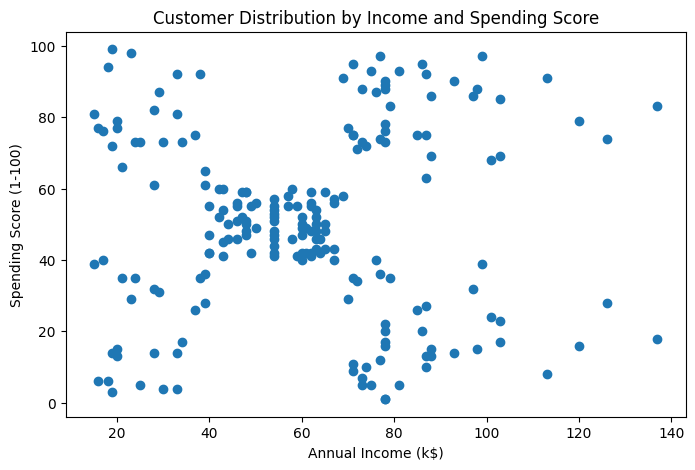

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.title('Customer Distribution by Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

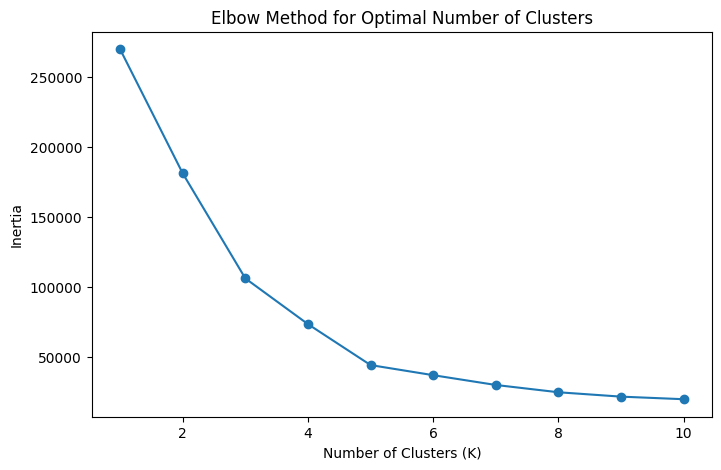

In [50]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

In [51]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


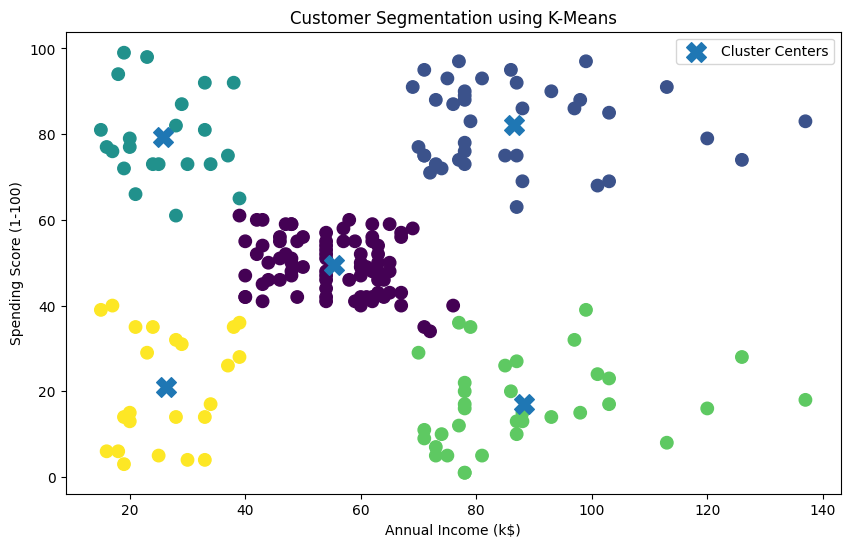

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    s=80
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    marker='X',
    label='Cluster Centers'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

plt.show()

In [53]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [54]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [55]:
segment_table = df.groupby('Cluster').agg(
    Number_of_Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

segment_table

,Number_of_Customers,Average_Age,Average_Income,Average_Spending_Score
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


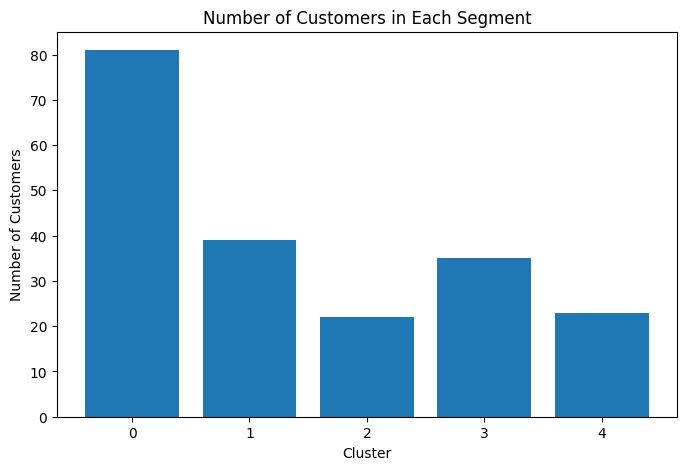

In [56]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

## Customer Segmentation Insights

The K-Means clustering algorithm divided the customers into five distinct segments based on Annual Income and Spending Score.

The clusters represent customers with different income and spending behaviors. These segments can help businesses understand their customer base and design more targeted marketing strategies.

The cluster summary was used to compare the average income, spending score, age, and number of customers in each segment.

In [57]:
cluster_profile = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(2)

cluster_profile

,Customers,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


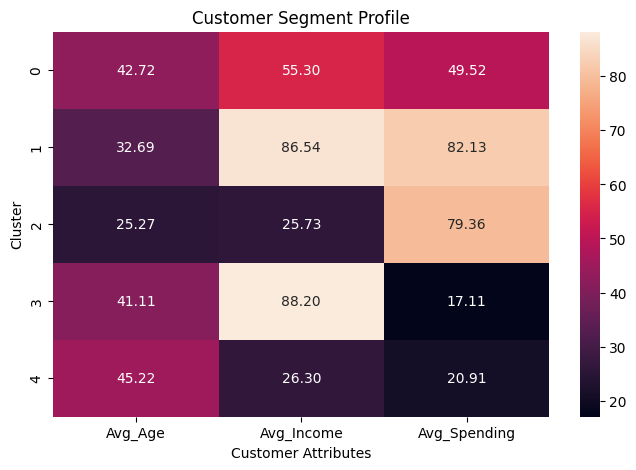

In [58]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile[['Avg_Age', 'Avg_Income', 'Avg_Spending']],
    annot=True,
    fmt='.2f'
)

plt.title('Customer Segment Profile')
plt.xlabel('Customer Attributes')
plt.ylabel('Cluster')

plt.show()

## Key Customer Segmentation Insights

The K-Means algorithm divided the customers into five distinct segments based on annual income and spending score.

The segments show different customer behaviors:

- Customers with higher income and higher spending scores represent valuable customers who may respond well to premium products and loyalty programs.
- Customers with higher income but lower spending scores may represent potential customers who could be targeted with personalized offers.
- Customers with lower income and higher spending scores show strong purchasing interest and may respond to affordable promotions.
- Customers with lower income and lower spending scores represent customers with relatively low purchasing activity.
- The remaining segment represents customers with moderate income and spending behavior.

These segments can help businesses develop targeted marketing strategies for different customer groups.

## Conclusion

Customer segmentation was performed using the K-Means clustering algorithm on the Mall Customer dataset. Annual Income and Spending Score were selected as the main features for identifying customer groups.

The Elbow Method was used to determine the appropriate number of clusters, resulting in five customer segments. The clusters were visualized and analyzed based on their income, spending behavior, age, and customer count.

This analysis demonstrates how clustering can help businesses understand different types of customers and develop more targeted marketing strategies.